## EDA of YouTube & Spotify Music Metrics

In [1]:
# === Data Loading & Log Transform Setup ===
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.subplots as sp
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Load dataset
part_one = pd.read_csv("clean_data.csv").copy()

# Create log-transformed columns to reduce skew
part_one["Log_Views"] = np.log1p(part_one["Views"])
part_one["Log_Likes"] = np.log1p(part_one["Likes"])
part_one["Log_Comments"] = np.log1p(part_one["Comments"])
part_one["Log_Stream"] = np.log1p(part_one["Stream"])


### heatmap

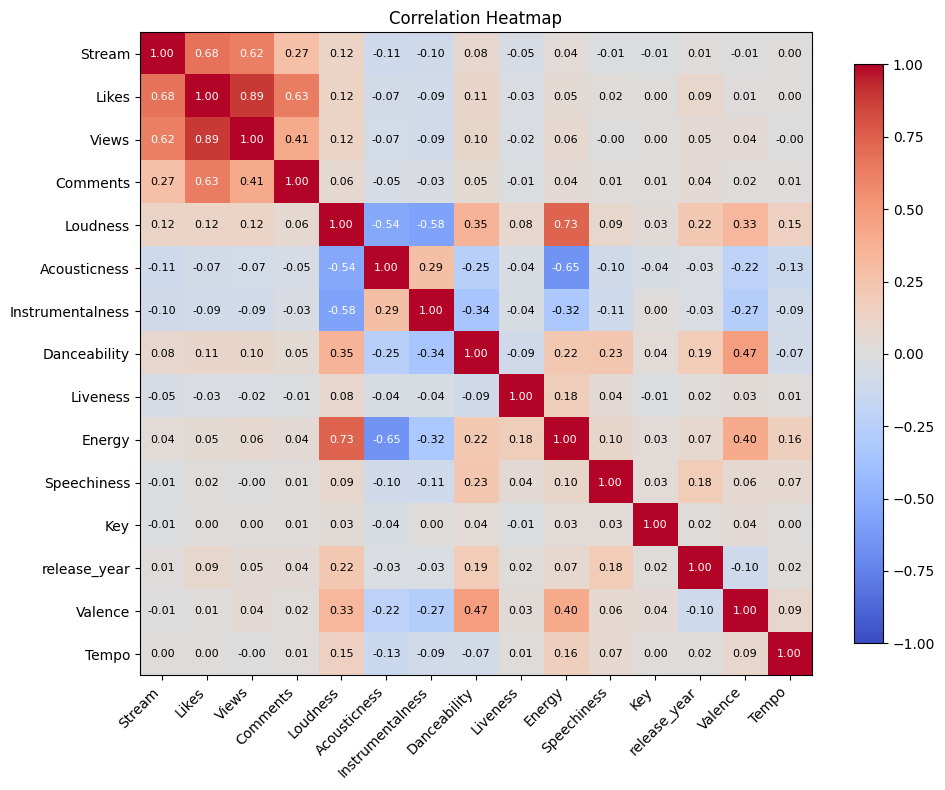

In [2]:
CSV = "clean_data.csv"
TARGET = "Stream"                 
MIN_NONNA_RATIO = 0.2             
SAVE_PATH = "corr_heatmap.png"                  

# 1) Load
df = pd.read_csv(CSV)

# 2) release_year from release_date / release_date_raw
def to_year(s):
    if pd.isna(s): return np.nan
    s = str(s)
    try:
        return int(s[:4])
    except Exception:
        return np.nan

if "release_date" in df.columns:
    df["release_year"] = df["release_date"].map(to_year)
elif "release_date_raw" in df.columns:
    df["release_year"] = df["release_date_raw"].map(to_year)

# 3) coerce booleans if present
for col in ["Licensed", "official_video"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.upper().map({"TRUE": 1, "FALSE": 0})
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 4) numeric candidates
cand_cols = [
    "Danceability","Energy","Key","Loudness","Speechiness","Acousticness",
    "Instrumentalness","Liveness","Valence","Tempo",
    "Views","Likes","Comments","Stream","release_year","Licensed","official_video"
]
num_cols = [c for c in cand_cols if c in df.columns]
num = df[num_cols].copy()
# 5) drop sparse or constant columns
keep = []
for c in num.columns:
    col = num[c]
    if col.notna().mean() < MIN_NONNA_RATIO:   # too sparse
        continue
    if col.nunique(dropna=True) <= 1:          # constant
        continue
    keep.append(c)
num = num[keep]

# If TARGET got dropped, fall back to the first numeric col
if TARGET not in num.columns:
    TARGET = num.columns[0]

# 6) correlation + reorder by |corr with TARGET|
corr = num.corr(method="pearson")
target_corr = corr[TARGET].abs().sort_values(ascending=False)
ordered_cols = [TARGET] + [c for c in target_corr.index if c != TARGET]
corr = corr.loc[ordered_cols, ordered_cols]

# 7) Plot with coolwarm centered at 0
fig, ax = plt.subplots(figsize=(10, 8))

# center colors at 0; symmetric limits based on max |corr|
max_abs = np.nanmax(np.abs(corr.values))
norm = TwoSlopeNorm(vcenter=0.0, vmin=-max_abs, vmax=max_abs)

im = ax.imshow(corr.values, cmap="coolwarm", norm=norm, aspect="auto")

cbar = fig.colorbar(im, ax=ax, shrink=0.9)

# ticks / labels
ax.set_xticks(range(len(ordered_cols)))
ax.set_yticks(range(len(ordered_cols)))
ax.set_xticklabels(ordered_cols, rotation=45, ha="right")
ax.set_yticklabels(ordered_cols)
ax.set_title("Correlation Heatmap".format(TARGET))

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        v = corr.iloc[i, j]
        txt = f"{v:.2f}" if pd.notna(v) else ""
        color = "white" if pd.notna(v) and abs(v) > 0.5 else "black"
        ax.text(j, i, txt, ha="center", va="center", fontsize=8, color=color)

fig.tight_layout()
if SAVE_PATH:
    plt.savefig(SAVE_PATH, dpi=200, bbox_inches="tight")


### Feature Distributions Across YouTube View Brackets

In [3]:
# --- ensure the Views bins exist once ---
if "Log_Views" not in part_one:
    part_one["Log_Views"] = np.log1p(part_one["Views"])
if "Views_bin" not in part_one:
    part_one["Views_bin"] = pd.qcut(
        part_one["Log_Views"], q=4, labels=["Low", "Medium", "High", "Very High"]
    )

def pair_plots_by_views(df, feat_a, feat_b, bin_col="Views_bin"):
    """Make boxplots for each feature vs Views bins and a combined violin."""
    # keep only rows we need
    keep = df[[bin_col, feat_a, feat_b]].dropna()

    # Boxplots
    fig_a = px.box(
        keep, x=bin_col, y=feat_a,
        title=f"{feat_a} Distribution by YouTube Views Brackets",
        labels={bin_col: "YouTube Views Bracket", feat_a: feat_a}
    )
    fig_b = px.box(
        keep, x=bin_col, y=feat_b,
        title=f"{feat_b} Distribution by YouTube Views Brackets",
        labels={bin_col: "YouTube Views Bracket", feat_b: feat_b}
    )

    # Combined violin
    melted = keep.melt(id_vars=[bin_col], value_vars=[feat_a, feat_b],
                       var_name="Feature", value_name="Value")
    fig_violin = px.violin(
        melted, x=bin_col, y="Value", color="Feature",
        box=True, points="all",
        title=f"{feat_a} vs {feat_b} across YouTube Views Brackets",
        labels={bin_col: "YouTube Views Bracket", "Value": "Value"}
    )
    return fig_a, fig_b, fig_violin

# --- Your existing pair (Instrumentalness vs Speechiness) ---
fig_instr_box, fig_speech_box, fig_instr_speech_violin = pair_plots_by_views(
    part_one, "Instrumentalness", "Speechiness"
)

# --- New pair 1: Loudness vs Valence ---
fig_loud_box, fig_val_box, fig_loud_val_violin = pair_plots_by_views(
    part_one, "Loudness", "Valence"
)

# --- New pair 2: Tempo vs Energy ---
fig_tempo_box, fig_energy_box, fig_tempo_energy_violin = pair_plots_by_views(
    part_one, "Tempo", "Energy"
)

fig_instr_box.show(); fig_speech_box.show(); fig_instr_speech_violin.show()
fig_loud_box.show();  fig_val_box.show();   fig_loud_val_violin.show()
fig_tempo_box.show(); fig_energy_box.show(); fig_tempo_energy_violin.show()


### Funnel-Based Interaction Efficiency Analysis

In [4]:
def _coerce_metrics(df, cols=("Views","Likes","Comments")):
    out = df.copy()
    for c in cols:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")
        else:
            raise ValueError(f"Missing column: {c}")
    return out

# -------------------------------------------------------------------
# Overall funnel
# -------------------------------------------------------------------
def funnel_overall(df):
    d = _coerce_metrics(df)
    totals = d[["Views","Likes","Comments"]].sum(min_count=1)
    stages = ["Views","Likes","Comments"]
    values = [totals["Views"], totals["Likes"], totals["Comments"]]

    # step conversion rates
    eps = 1e-9
    like_rate = totals["Likes"] / (totals["Views"] + eps)
    comment_rate_vs_like = totals["Comments"] / (totals["Likes"] + eps)
    comment_rate_vs_view = totals["Comments"] / (totals["Views"] + eps)

    fig = go.Figure(go.Funnel(
        y=stages,
        x=values,
        textposition="auto",
        text=[f"{v:,.0f}" for v in values],
        opacity=0.9
    ))
    fig.update_layout(
        title=f"Overall Funnel: Views → Likes → Comments  "
              f"(Like/View={like_rate:.2%}, Comment/Like={comment_rate_vs_like:.2%}, "
              f"Comment/View={comment_rate_vs_view:.2%})",
        height=500, margin=dict(l=60, r=40, t=80, b=40)
    )
    return fig

def funnel_by_category(df, cat_col="Album_type", top_k=6):
    d = _coerce_metrics(df)
    if cat_col not in d.columns:
        raise ValueError(f"Missing category column: {cat_col}")

    g = (d.groupby(cat_col, dropna=False)[["Views","Likes","Comments"]]
           .sum(min_count=1))
    # choose top_k by Views volume
    top = g.sort_values("Views", ascending=False).head(top_k).reset_index()

    n = len(top)
    rows = int(np.ceil(n / 3))
    cols = min(3, n)

    fig = make_subplots(rows=rows, cols=cols,
                        subplot_titles=[str(c) for c in top[cat_col]],
                        horizontal_spacing=0.10, vertical_spacing=0.12)

    for i, (_, row) in enumerate(top.iterrows()):
        r = i // cols + 1
        c = i % cols + 1

        stages = ["Views","Likes","Comments"]
        values  = [row["Views"], row["Likes"], row["Comments"]]

        fig.add_trace(
            go.Funnel(y=stages, x=values, text=[f"{v:,.0f}" for v in values],
                      textposition="auto", opacity=0.9, showlegend=False),
            row=r, col=c
        )

        # annotate step rates inside each facet
        eps = 1e-9
        like_rate  = row["Likes"]    / (row["Views"] + eps)
        comm_rateL = row["Comments"] / (row["Likes"] + eps)
        fig.add_annotation(
            row=r, col=c, x=0.5, y=1.12, xref=f"x{'' if (r,c)==(1,1) else r*cols - (cols-c)} domain",
            yref=f"y{'' if (r,c)==(1,1) else r*cols - (cols-c)} domain",
            text=f"Like/View={like_rate:.1%} · Comment/Like={comm_rateL:.1%}",
            showarrow=False, font=dict(size=11)
        )

    fig.update_layout(title=f"Funnel by {cat_col} (top {top_k} by Views)",
                      height=380*rows, margin=dict(l=60, r=40, t=80, b=40))
    return fig

def interaction_diagnostics(df, cat_col="Album_type", min_views=1e6):
    d = _coerce_metrics(df)
    g = (d.groupby(cat_col, dropna=False)[["Views","Likes","Comments"]]
           .sum(min_count=1))
    eps = 1e-9
    g["like_rate"]      = g["Likes"]    / (g["Views"] + eps)
    g["comment_rate_V"] = g["Comments"] / (g["Views"] + eps)
    g["comment_rate_L"] = g["Comments"] / (g["Likes"] + eps)
    # focus on categories with enough total Views, then sort by low interaction
    out = (g[g["Views"] >= min_views]
             .sort_values(["like_rate","comment_rate_V"], ascending=[True, True]))
    return out


df = pd.read_csv("clean_data.csv") 

fig_overall = funnel_overall(df)
fig_overall.show()


fig_album = funnel_by_category(df, cat_col="Album_type", top_k=6)
fig_album.show()
fig_official = funnel_by_category(df, cat_col="official_video", top_k=2)
fig_official.show()

diag = interaction_diagnostics(df, cat_col="Album_type", min_views=5_000_000)
print(diag.head(10))


                    Views         Likes     Comments  like_rate  \
Album_type                                                        
compilation  4.670502e+10  3.023632e+08    9505631.0   0.006474   
album        1.283156e+12  8.372029e+09  369528997.0   0.006525   
single       3.176588e+11  2.661275e+09   99996410.0   0.008378   

             comment_rate_V  comment_rate_L  
Album_type                                   
compilation        0.000204        0.031438  
album              0.000288        0.044139  
single             0.000315        0.037575  


### Cross-Platform Reach: Spotify Streams vs. YouTube Views (Raw & Log-Scale)

In [5]:
def plot_streams_vs_views(df,
                          stream_col="Stream",
                          views_col="Views"):

    # --- 1) Raw scale scatter -----------------
    fig_raw = px.scatter(
        df,
        x=stream_col,
        y=views_col,
        opacity=0.4,
        title="YouTube Views vs Spotify Streams (raw scale)",
        labels={
            stream_col: "Spotify Streams",
            views_col: "YouTube Views"
        }
    )
    fig_raw.update_traces(marker=dict(size=5))
    fig_raw.update_layout(
        template="simple_white",
        font=dict(size=14),
    )

    # --- 2) Log scale scatter -----------------
    # avoid log of 0
    d2 = df.copy()
    d2["log_stream"] = np.log(d2[stream_col] + 1)
    d2["log_views"]  = np.log(d2[views_col] + 1)

    fig_log = px.scatter(
        d2,
        x="log_stream",
        y="log_views",
        opacity=0.5,
        trendline="ols", 
        title="log(Stream) vs log(Views)",
        labels={
            "log_stream": "log(Spotify Streams + 1)",
            "log_views": "log(YouTube Views + 1)"
        },
        color="log_views"  
    )
    fig_log.update_traces(marker=dict(size=5))
    fig_log.update_layout(
        coloraxis_colorbar_title="log(Views)",
        template="simple_white",
        font=dict(size=14),
    )

    return fig_raw, fig_log

# ---------------- run ----------------
fig_raw, fig_log = plot_streams_vs_views(df)

fig_raw.show()
fig_log.show()


/Users/jingchang/opt/anaconda3/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:7: FutureWarning:

pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.

/Users/jingchang/opt/anaconda3/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:7: FutureWarning:

pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.



### Audio Feature Distributions Across YouTube Popularity Brackets (Violin + Box)

In [6]:
def plot_feature_vs_views_bracket(df,
                                  views_col="Views",
                                  features=("Valence", "Speechiness", "Energy", "Key"),
                                  n_brackets=4,
                                  bracket_labels=("Low", "Medium", "High", "Very High")):

    d = df.copy()

    # --- create quantile brackets on Views ---
    # we take log(Views+1) first so extreme outliers don't eat all the upper bin
    d["_log_views"] = np.log(d[views_col] + 1)

    # qcut -> equal-frequency bins
    d["_views_bracket"] = pd.qcut(
        d["_log_views"],
        q=n_brackets,
        labels=bracket_labels
    )

    # --- build subplot figure: 2 rows x 2 cols (for 4 features) ---
    rows = 2
    cols = 2
    fig = sp.make_subplots(
        rows=rows,
        cols=cols,
        subplot_titles=[f"{feat} vs Views Bracket" for feat in features],
        horizontal_spacing=0.12,
        vertical_spacing=0.18
    )

    # helper to map index -> (row, col)
    def rc_from_idx(i):
        return (i // cols) + 1, (i % cols) + 1

    palette = {
        "Valence": "#ff7f0e",
        "Speechiness": "#2ca02c",
        "Energy": "#d62728",
        "Key": "#1f77b4"
    }

    for i, feat in enumerate(features):
        r, c = rc_from_idx(i)

        # violin trace (distribution shape)
        fig.add_trace(
            go.Violin(
                x=d["_views_bracket"],
                y=d[feat],
                name=feat,
                legendgroup=feat,
                scalegroup=feat,
                line_color=palette.get(feat, "#636efa"),
                fillcolor="rgba(0,0,0,0)",
                opacity=0.5,
                points="all",        # show individual points
                pointpos=0.0,
                jitter=0.2,
                scalemode="width",
                spanmode="soft",
                showlegend=False
            ),
            row=r, col=c
        )

        # box trace (summary: median / IQR)
        fig.add_trace(
            go.Box(
                x=d["_views_bracket"],
                y=d[feat],
                name=feat,
                legendgroup=feat,
                marker_color=palette.get(feat, "#636efa"),
                boxmean=True,
                fillcolor="rgba(255,255,255,0.6)",
                line=dict(width=2),
                showlegend=(i == 0),  # only show legend once
            ),
            row=r, col=c
        )

        fig.update_xaxes(
            title_text="YouTube Views Bracket",
            row=r,
            col=c,
            categoryorder="array",
            categoryarray=list(bracket_labels),
        )
        fig.update_yaxes(
            title_text=feat if feat != "Key" else "Key (pitch class)",
            row=r,
            col=c
        )

    fig.update_layout(
        title="Audio Feature Distributions across YouTube Popularity Brackets",
        template="simple_white",
        font=dict(size=14),
        height=800,
        width=1100
    )

    return fig

# ---------- run ----------
fig_features = plot_feature_vs_views_bracket(df)
fig_features.show()


### Long-Term Trend Analysis of Audio Features and Audience Reach (7-Year Rolling Medians)

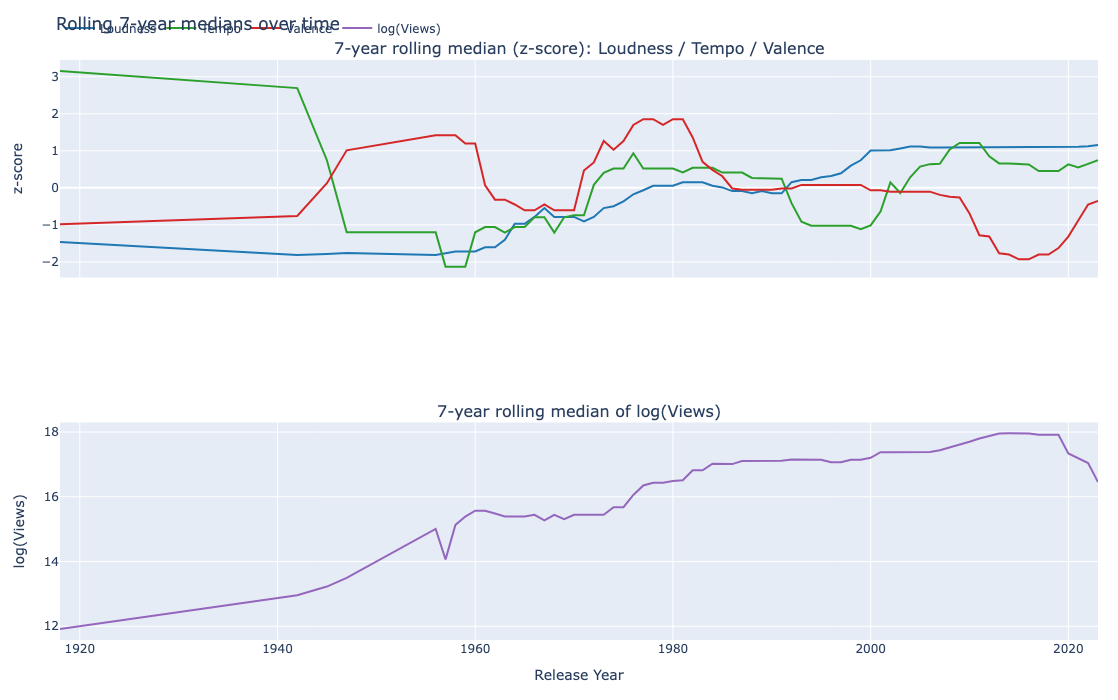

In [7]:
df = pd.read_csv("clean_data.csv") 
def to_year(s):
    if pd.isna(s): 
        return np.nan
    s = str(s)
    try:
        return int(s[:4])
    except:
        return np.nan

if "release_date" in df.columns:
    df["release_year"] = df["release_date"].map(to_year)
elif "release_date_raw" in df.columns:
    df["release_year"] = df["release_date_raw"].map(to_year)
else:
    raise ValueError("No release_date or release_date_raw column found.")

# numeric coercion
for c in ["Views", "Loudness", "Tempo", "Valence"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["release_year"])

# ----------------------------------------------
# 2) Yearly medians + 7-year rolling medians
# ----------------------------------------------
yearly = (
    df.groupby("release_year", as_index=True)
      .agg({
          "Loudness": "median",
          "Tempo": "median",
          "Valence": "median",
          "Views": "median"
      })
      .sort_index()
)

# log-transform views for stability
yearly["log_views"] = np.log1p(yearly["Views"])

# rolling (7-year window), use center=True for nicer alignment
roll = yearly[["Loudness", "Tempo", "Valence", "log_views"]].rolling(
    window=7, center=True, min_periods=3
).median()

# Optional: normalize audio features for comparable scales (z-score per series)
norm = roll.copy()
for col in ["Loudness", "Tempo", "Valence"]:
    s = norm[col]
    norm[col] = (s - s.mean(skipna=True)) / s.std(skipna=True)

# ---------------------------------------------------
# 3) Plot: audio features (normalized) vs log(Views)
# ---------------------------------------------------
fig = make_subplots(
    rows=2, cols=1, shared_xaxes=True,
    subplot_titles=("7-year rolling median (z-score): Loudness / Tempo / Valence",
                    "7-year rolling median of log(Views)")
)

# audio curves (normalized z-scores)
x = norm.index
for col, color in [("Loudness", "#1f77b4"), ("Tempo", "#2ca02c"), ("Valence", "#d62728")]:
    fig.add_trace(
        go.Scatter(x=x, y=norm[col], name=col, mode="lines", line=dict(width=2, color=color)),
        row=1, col=1
    )

# views curve (log)
fig.add_trace(
    go.Scatter(x=x, y=roll["log_views"], name="log(Views)", mode="lines", line=dict(width=2, color="#9467bd")),
    row=2, col=1
)

fig.update_xaxes(title_text="Release Year", row=2, col=1)
fig.update_yaxes(title_text="z-score", row=1, col=1, zeroline=True)
fig.update_yaxes(title_text="log(Views)", row=2, col=1)

fig.update_layout(
    title="Rolling 7-year medians over time",
    legend_orientation="h", legend_y=1.08, legend_x=0,
    height=700, margin=dict(l=60, r=20, t=60, b=60)
)

fig.show()